# San Cristóbal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Tensorflow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential,save_model,load_model
from keras.layers import Dense
from keras.layers import LSTM
from keras.callbacks import EarlyStopping
from keras.metrics import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import keras

#Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dropout, Input
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error

In [3]:
train_serie = pd.read_csv(
    "../../Datos/san_cristobal_train.csv",
    index_col=0,
    parse_dates=True
)["Viajero"]

test_serie = pd.read_csv(
    "../../Datos/san_cristobal_test.csv",
    index_col=0,
    parse_dates=True
)["Viajero"]

In [4]:
tf.random.set_seed(123)
np.random.seed(123)

def crear_secuencias(datos_escalados, ventana):
    X, y = [], []
    for i in range(len(datos_escalados) - ventana):
        X.append(datos_escalados[i:i+ventana, 0])
        y.append(datos_escalados[i+ventana, 0])
    return np.array(X), np.array(y)

def construir_modelo(ventana, capas_unidades, dropout, lr):
    modelo = Sequential()
    modelo.add(Input(shape=(ventana, 1)))
    for idx, unidades in enumerate(capas_unidades):
        return_seq = idx < len(capas_unidades) - 1
        modelo.add(LSTM(unidades, return_sequences=return_seq))
        modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    modelo.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return modelo

def evaluar_config(train_serie, ventana, capas_unidades, dropout, lr, batch_size, epochs=100):
    """Entrena con un split interno 80/20 (cronológico) y devuelve RMSE/MAE de validación."""
    valores = train_serie.values.reshape(-1,1).astype(float)

    corte = int(len(valores) * 0.8)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(valores[:corte])  # ajustar SOLO con la parte de entrenamiento real
    valores_esc = scaler.transform(valores)

    X, y = crear_secuencias(valores_esc, ventana)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    corte_secuencias = corte - ventana
    X_train, y_train = X[:corte_secuencias], y[:corte_secuencias]
    X_val, y_val = X[corte_secuencias:], y[corte_secuencias:]

    modelo = construir_modelo(ventana, capas_unidades, dropout, lr)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)

    pred_val = scaler.inverse_transform(modelo.predict(X_val, verbose=0))
    real_val = scaler.inverse_transform(y_val.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(real_val, pred_val))
    mae = mean_absolute_error(real_val, pred_val)
    return rmse, mae

# --- Grid de evidencia: variamos ventana, unidades, capas, dropout y lr ---
grid = [
    {'nombre': 'A: ventana6_1capa32',  'ventana': 6,  'capas_unidades': [32],     'dropout': 0.1, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_1capa32',    'ventana': 12, 'capas_unidades': [32],     'dropout': 0.1, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'B: ventana12_1capa50', 'ventana': 12, 'capas_unidades': [50],     'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana6_2capas',      'ventana': 6,  'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_2capas',     'ventana': 12, 'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_2capas_lrbajo', 'ventana': 12, 'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 16},
]

resultados = []
for cfg in grid:
    rmse, mae = evaluar_config(train_serie, cfg['ventana'], cfg['capas_unidades'],
                                cfg['dropout'], cfg['lr'], cfg['batch_size'])
    resultados.append({'Config': cfg['nombre'], 'RMSE_val': round(rmse, 2), 'MAE_val': round(mae, 2)})
    print(f"{cfg['nombre']:24s} | RMSE_val={rmse:9.2f} | MAE_val={mae:9.2f}")

df_resultados = pd.DataFrame(resultados).sort_values('RMSE_val')
print("\nRanking (menor RMSE de validación = mejor):")
print(df_resultados.to_string(index=False))

A: ventana6_1capa32      | RMSE_val=  9585.58 | MAE_val=  7440.01
ventana12_1capa32        | RMSE_val= 12459.09 | MAE_val= 10067.49
B: ventana12_1capa50     | RMSE_val= 12666.06 | MAE_val= 10206.22
ventana6_2capas          | RMSE_val= 10565.88 | MAE_val=  8470.19
ventana12_2capas         | RMSE_val= 13279.10 | MAE_val= 11406.51
ventana12_2capas_lrbajo  | RMSE_val= 13411.61 | MAE_val= 11881.05

Ranking (menor RMSE de validación = mejor):
                 Config  RMSE_val  MAE_val
    A: ventana6_1capa32   9585.58  7440.01
        ventana6_2capas  10565.88  8470.19
      ventana12_1capa32  12459.09 10067.49
   B: ventana12_1capa50  12666.06 10206.22
       ventana12_2capas  13279.10 11406.51
ventana12_2capas_lrbajo  13411.61 11881.05


In [5]:
# Convertir a numpy
train_valores = train_serie.values.reshape(-1, 1)
test_valores = test_serie.values.reshape(-1, 1)

# Escalar usando SOLO el entrenamiento
scaler = MinMaxScaler(feature_range=(0, 1))
train_escalado = scaler.fit_transform(train_valores)
test_escalado = scaler.transform(test_valores)

## LSTM 1

In [6]:
ventana = 6 

X_train, y_train = crear_secuencias(train_escalado, ventana)
X_test, y_test = crear_secuencias(test_escalado, ventana)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [8]:
paso = 6
caracteristicas = 1
unidades = 32

inputs = keras.layers.Input(shape=(paso, caracteristicas))

x = keras.layers.LSTM(unidades)(inputs)
x = keras.layers.Dropout(0.1)(x)

outputs = keras.layers.Dense(1)(x)

modelo1 = keras.Model(inputs=inputs, outputs=outputs)

modelo1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

modelo1.summary()

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 6, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
epocas = 100
batch_size = 8

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history1 = modelo1.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epocas,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2020 - root_mean_squared_error: 0.4494 - val_loss: 0.1377 - val_root_mean_squared_error: 0.3710
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0662 - root_mean_squared_error: 0.2574 - val_loss: 0.0735 - val_root_mean_squared_error: 0.2712
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0359 - root_mean_squared_error: 0.1896 - val_loss: 0.0456 - val_root_mean_squared_error: 0.2136
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0260 - root_mean_squared_error: 0.1612 - val_loss: 0.0345 - val_root_mean_squared_error: 0.1858
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0287 - root_mean_squared_error: 0.1693 - val_loss: 0.0304 - val_root_mean_squared_error: 0.1744
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0226 - root_mean_squared_error: 0.1502 - val_loss: 0.0304 - val_root_mean_squared_error: 0.1743
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

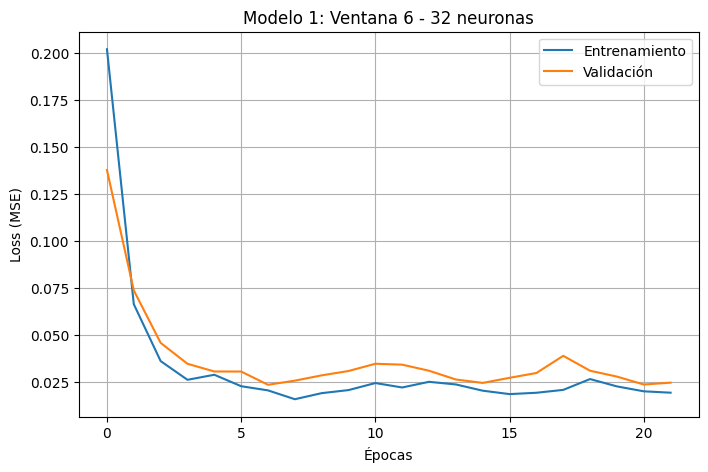

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['loss'], label='Entrenamiento')
plt.plot(history1.history['val_loss'], label='Validación')

plt.title('Modelo 1: Ventana 6 - 32 neuronas')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

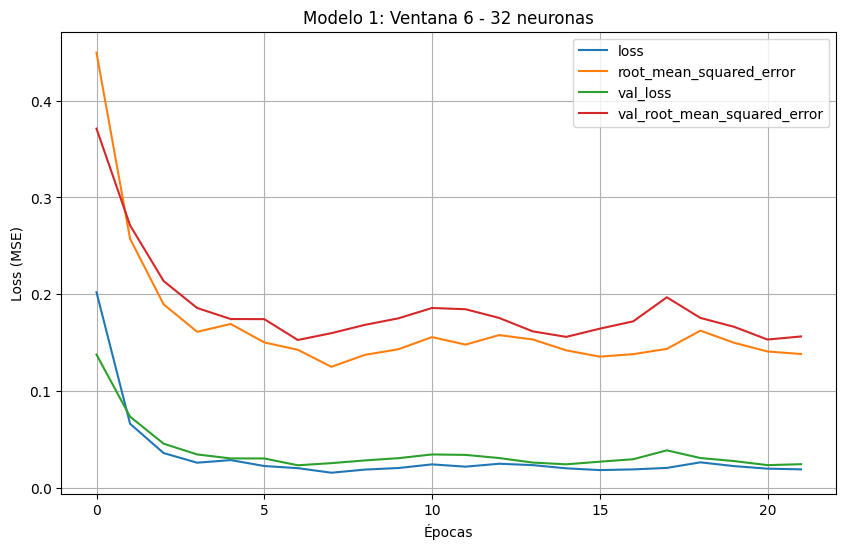

In [15]:
losses_df1 = pd.DataFrame(history1.history)

losses_df1.plot(figsize=(10,6))

plt.title("Modelo 1: Ventana 6 - 32 neuronas")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

In [19]:
print("Pérdida en Entrenamiento")
modelo1.evaluate(
    x = X_train,
    y = y_train
)

print("Pérdida en Prueba")
modelo1.evaluate(
    x = X_test,
    y = y_test
)

Pérdida en Entrenamiento
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0171 - root_mean_squared_error: 0.1306 
Pérdida en Prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0198 - root_mean_squared_error: 0.1407


[0.0197877399623394, 0.14066889882087708]

In [21]:
def prediccion_fun(data, modelo1, scaler):
    pred = modelo1.predict(data, verbose=0)
    pred = scaler.inverse_transform(pred)
    return pred.flatten()

In [24]:
print("X_test:", X_test.shape)
print("Modelo:", modelo1)

X_test: (57, 6, 1)
Modelo: <Functional name=functional_24, built=True>


In [25]:
prediccion_test = modelo1.predict(X_test, verbose=0)

# Regresar a la escala original
prediccion_test = scaler.inverse_transform(prediccion_test)

# Valores reales en la escala original
real_test = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

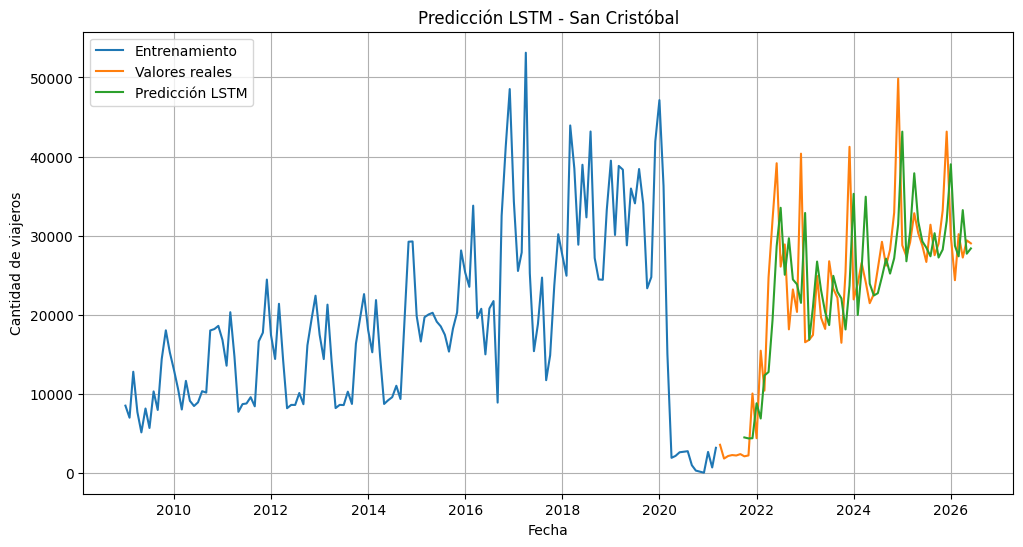

In [28]:
df_pred = pd.DataFrame(
    prediccion_test,
    index=test_serie.index[ventana:],
    columns=["Predicción"]
)

plt.figure(figsize=(12,6))

plt.plot(train_serie.index, train_serie.values, label="Entrenamiento")
plt.plot(test_serie.index, test_serie.values, label="Valores reales")
plt.plot(df_pred.index, df_pred["Predicción"], label="Predicción LSTM")

plt.title("Predicción LSTM - San Cristóbal")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
save_model(modelo1, "../../Modelos/lstm3_serie_tiempo.keras")

## LSTM 2

In [7]:
ventana = 6 

X_train, y_train = crear_secuencias(train_escalado, ventana)
X_test, y_test = crear_secuencias(test_escalado, ventana)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [9]:
paso = 6
caracteristicas = 1

inputs = keras.layers.Input(shape=(paso, caracteristicas))

x = keras.layers.LSTM(64, return_sequences=True)(inputs)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.LSTM(32)(x)
x = keras.layers.Dropout(0.2)(x)

outputs = keras.layers.Dense(1)(x)

modelo2 = keras.Model(inputs=inputs, outputs=outputs)

modelo2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

modelo2.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 6, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 6, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
epocas = 100
batch_size = 8

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history2 = modelo2.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epocas,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0570 - val_loss: 0.0579
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0323 - val_loss: 0.0563
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0277 - val_loss: 0.0550
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0277 - val_loss: 0.0543
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0251 - val_loss: 0.0536
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0270 - val_loss: 0.0529
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0280 - val_loss: 0.0518
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0246 - val_loss: 0.0512
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0250 - val_loss: 0.0506
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0212 - val_loss: 0.0510
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0272 - val_loss: 0.0498
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

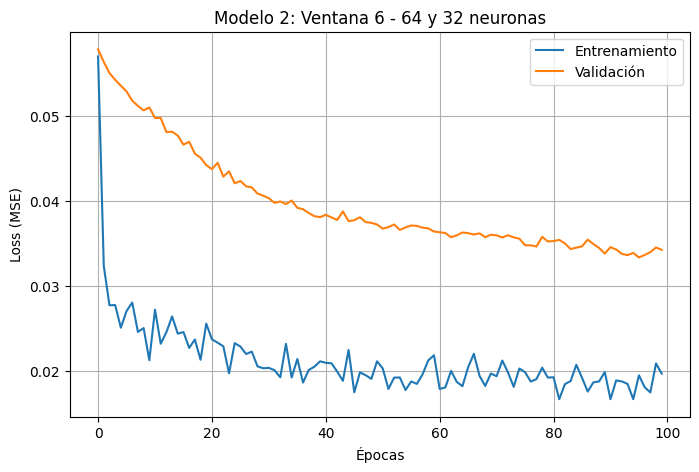

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history2.history['loss'], label='Entrenamiento')
plt.plot(history2.history['val_loss'], label='Validación')

plt.title('Modelo 2: Ventana 6 - 64 y 32 neuronas')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

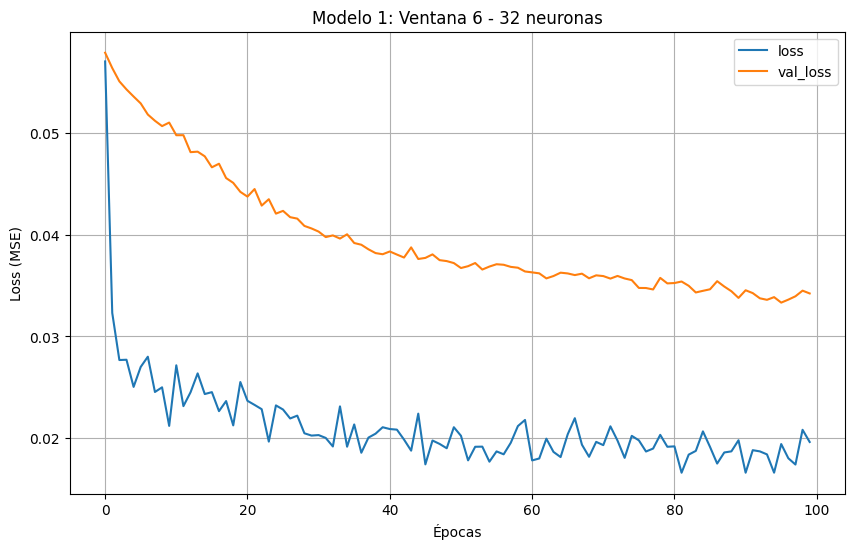

In [18]:
losses_df2 = pd.DataFrame(history2.history)

losses_df2.plot(figsize=(10,6))

plt.title("Modelo 1: Ventana 6 - 32 neuronas")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

In [20]:
print("Pérdida en Entrenamiento")
modelo2.evaluate(
    x = X_train,
    y = y_train
)

print("Pérdida en Prueba")
modelo2.evaluate(
    x = X_test,
    y = y_test
)

Pérdida en Entrenamiento
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0199 
Pérdida en Prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0205


0.020500408485531807

In [22]:
def prediccion_fun(data, modelo2, scaler):
    pred = modelo2.predict(data, verbose=0)
    pred = scaler.inverse_transform(pred)
    return pred.flatten()

In [23]:
print("X_test:", X_test.shape)
print("Modelo:", modelo2)

X_test: (57, 6, 1)
Modelo: <Functional name=functional_25, built=True>


In [26]:
prediccion_test2 = modelo2.predict(X_test, verbose=0)

# Regresar a la escala original
prediccion_test2 = scaler.inverse_transform(prediccion_test2)

# Valores reales en la escala original
real_test2 = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

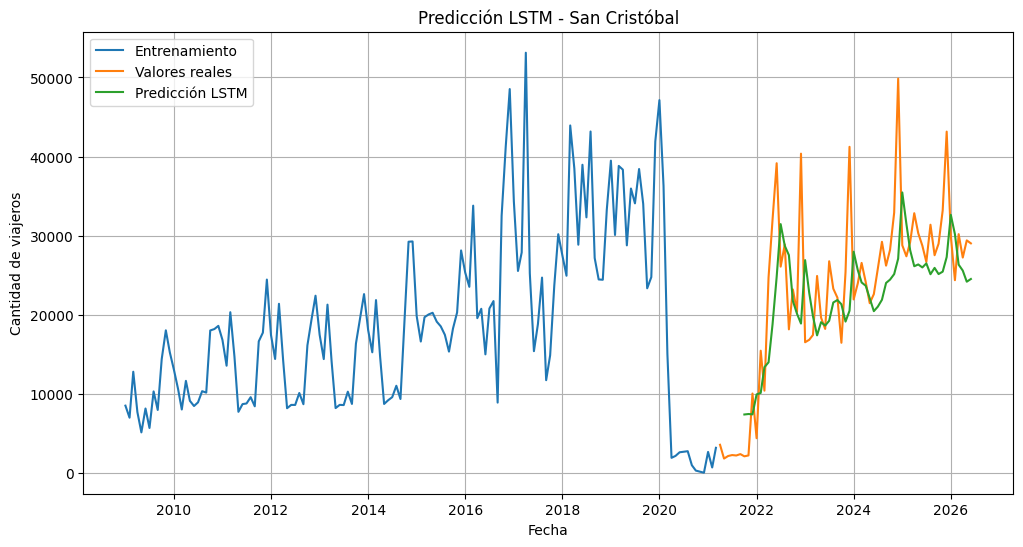

In [27]:
df_pred2 = pd.DataFrame(
    prediccion_test2,
    index=test_serie.index[ventana:],
    columns=["Predicción"]
)

plt.figure(figsize=(12,6))

plt.plot(train_serie.index, train_serie.values, label="Entrenamiento")
plt.plot(test_serie.index, test_serie.values, label="Valores reales")
plt.plot(df_pred2.index, df_pred2["Predicción"], label="Predicción LSTM")

plt.title("Predicción LSTM - San Cristóbal")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
save_model(modelo2, "../../Modelos/lstm4_serie_tiempo.keras")